# Analysis of the results

#### Setting up the environment

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stats
import seaborn as sns

#### Results import

In [3]:
heuristics = ["FCFS", "LCFS", "SJF","LJF","CD","LBW","WS"]
variances = [0.0000, 0.0010, 0.0017, 0.0030, 0.0044, 0.0065, 0.0095, 0.0138, 0.0201, 0.0292, 0.0425, 0.0619, 0.0901, 0.1311, 0.1908, 0.2772, 0.4026, 0.5848, 0.8496, 1.0000]
n_v = len(variances)

taskData = {}

In [4]:
Tdata = [[[] for j in range(n_v)] for i in range(7)]
Wdata = [[[] for j in range(n_v)] for i in range(7)]
Sdata = [[] for i in range(7)]
for h_id in range(7): #per heuristic
    for v_id in range(n_v): #per test set / variance parameter
        with open(f"../results/{h_id}_{v_id}.txt", mode='r') as f:
            raw = f.readlines()

        worker_lines = []
        for line in raw:
            if line[0] == 'W':
                Wdata[h_id][v_id].append((float(line.split(sep=';')[2][2:].strip('\n')), 
                                      float(line.split(sep=';')[1][2:]))) #add tuple (task time, overhead)
            elif line[0] == 'M':
                Sdata[h_id].append(float(line.split(':')[1])) #add scheduler scheduling time
            elif line[0] == 'T':
                Tdata[h_id][v_id].append((float(line.split(';')[0][2:]), #Task ID
                                          float(line.split(';')[1][2:]), #Worker ID
                                          float(line.split(';')[2][2:]), #Task time
                                          line.split(';')[3][2:])) #Queue time
        worker_lines.sort()
        
n_worker = len(Wdata[0][0])


##### Creation of DataFrames

In [5]:
# Task DataFrame

records = []
for v_id, var in enumerate(variances):
    for h_id, heuristic in enumerate(heuristics):
        for task in Tdata[h_id][v_id]:
            records.append({
                'Heuristic': heuristic,
                'Variance': var,
                'TaskID': task[0],
                'WorkerID': task[1],
                'TaskTime': task[2],
                'QueueTime': float(task[3])
            })
Tdf=pd.DataFrame.from_records(records)

In [6]:
# Worker DataFrame
records = []
for v_id, var in enumerate(variances):
    for h_id, heuristic in enumerate(heuristics):
        for w_id in range(n_worker):
            total_task_time = Wdata[h_id][v_id][w_id][0]
            total_overhead = Wdata[h_id][v_id][w_id][1]
            records.append({
                'Heuristic': heuristic,
                'Variance': var,
                'WorkerID': w_id,
                'TotalTaskTime': total_task_time,
                'TotalOverhead': total_overhead
            })
Wdf=pd.DataFrame.from_records(records)

##### Calculations

In [7]:
std_tasks = {heuristic: [] for heuristic in heuristics}
avg_tasks = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        tasks = [entry[0] for entry in Wdata[h_id][v_id]]
        std_tasks[heuristic].append(np.std(tasks))
        avg_tasks[heuristic].append(np.mean(tasks))

std_overheads = {heuristic: [] for heuristic in heuristics}
avg_overheads = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        overheads = [entry[1] for entry in Wdata[h_id][v_id]]
        std_overheads[heuristic].append(np.std(overheads))
        avg_overheads[heuristic].append(np.mean(overheads))

Wdata: Worker data, Wdata[Heuristic][Variance][worker] = (total task time, overhead)

Tdata: Task data, Tdata[Heuristic][Variance] = [task times]

### Table Generation

#### Work sets analysis

In [8]:
#### Sets analysis
records = []

for i, v in enumerate(variances):
    df = pd.read_csv(
        f"../tasks/{i}.txt",
        sep=r"\s+",
        engine="python",
        skiprows=1,
        skipfooter=1,
        names=["Delay", "Zoom", "MaxIter", "Resolution", "EstimatedCost"]
    )
    for val in df["EstimatedCost"]:
        records.append({"Variance": float(v), "EstimatedCost": val})

    summary = df.agg(["mean", "std"])
    print(f"Variance {v}:\n", summary)

Variance 0.0:
            Delay   Zoom  MaxIter  Resolution  EstimatedCost
mean  123.300000  5.005   1250.0       500.0   5.310640e+02
std    41.110279  0.000      0.0         0.0   1.137153e-13
Variance 0.001:
            Delay      Zoom      MaxIter  Resolution  EstimatedCost
mean  122.847500  5.005096  1249.489000  499.526000     529.843719
std    40.962156  0.004850     0.816218    0.500449       1.122740
Variance 0.0017:
            Delay      Zoom      MaxIter  Resolution  EstimatedCost
mean  122.844500  5.005221  1249.499000  499.492500     529.780404
std    40.961155  0.008653     1.317523    0.588317       1.406038
Variance 0.003:
            Delay      Zoom     MaxIter  Resolution  EstimatedCost
mean  122.851000  5.004769  1249.54850  499.521000     529.850303
std    40.963616  0.014940     2.26941    0.926276       2.236230
Variance 0.0044:
            Delay      Zoom      MaxIter  Resolution  EstimatedCost
mean  122.865500  5.004687  1249.585500  499.451500     529.717462
s

In [9]:
for v_id, var in enumerate(variances):
    subset = Wdf[Wdf["Variance"] == var]
    print(f"Variance {var}:")
    print(subset["TotalTaskTime"].agg(["mean", "std"]))

Variance 0.0:
mean    439.863831
std       0.866212
Name: TotalTaskTime, dtype: float64
Variance 0.001:
mean    441.649299
std       1.410641
Name: TotalTaskTime, dtype: float64
Variance 0.0017:
mean    441.129973
std       0.803069
Name: TotalTaskTime, dtype: float64
Variance 0.003:
mean    440.997273
std       0.717933
Name: TotalTaskTime, dtype: float64
Variance 0.0044:
mean    440.953195
std       0.742828
Name: TotalTaskTime, dtype: float64
Variance 0.0065:
mean    441.300001
std       0.707900
Name: TotalTaskTime, dtype: float64
Variance 0.0095:
mean    440.976155
std       0.735484
Name: TotalTaskTime, dtype: float64
Variance 0.0138:
mean    441.034532
std       0.888533
Name: TotalTaskTime, dtype: float64
Variance 0.0201:
mean    440.865217
std       0.846193
Name: TotalTaskTime, dtype: float64
Variance 0.0292:
mean    440.360681
std       0.588471
Name: TotalTaskTime, dtype: float64
Variance 0.0425:
mean    442.555397
std       4.198759
Name: TotalTaskTime, dtype: float64
Vari

#### Aggregate scheduler performances

In [10]:
decimals = 5

In [11]:
# Task time aggregate table
agg_df = Wdf.groupby(["Variance", "Heuristic"])["TotalTaskTime"].agg(["mean", "std"]).unstack("Heuristic")

# Format mean and std with fixed decimals
combined = (
    agg_df["mean"].map(lambda x: f"{x:.{decimals}f}")
    + " ± "
    + agg_df["std"].map(lambda x: f"{x:.{decimals}f}")
)

print(combined)

Heuristic                    CD                 FCFS                  LBW  \
Variance                                                                    
0.0000      439.25236 ± 0.72065  441.13776 ± 0.62343  439.42214 ± 0.70493   
0.0010      440.97962 ± 0.65644  441.85394 ± 0.59458  440.65452 ± 0.64782   
0.0017      440.60829 ± 0.68833  441.95401 ± 0.60401  440.43852 ± 0.64008   
0.0030      440.49341 ± 0.63604  441.68874 ± 0.60354  440.58302 ± 0.66561   
0.0044      440.81002 ± 0.69823  441.61698 ± 0.56212  440.45178 ± 0.52199   
0.0065      440.97035 ± 0.62437  442.06256 ± 0.52349  441.06458 ± 0.66828   
0.0095      440.65054 ± 0.73734  441.93829 ± 0.52075  440.78251 ± 0.87041   
0.0138      440.61685 ± 0.92630  441.99892 ± 0.45935  440.62002 ± 0.60304   
0.0201      440.65987 ± 1.20256  441.60379 ± 0.49308  440.41986 ± 0.71826   
0.0292      440.06739 ± 0.92520  440.88053 ± 0.44399  440.08664 ± 0.43992   
0.0425      440.93724 ± 1.34709  452.49759 ± 0.45551  439.51762 ± 0.40571   

In [12]:
# Task time aggregate table
agg_df = Wdf.groupby(["Variance", "Heuristic"])["TotalOverhead"].agg(["mean", "std"]).unstack("Heuristic")

# Format mean and std with fixed decimals
combined = (
    agg_df["mean"].map(lambda x: f"{x:.{decimals}f}")
    + " ± "
    + agg_df["std"].map(lambda x: f"{x:.{decimals}f}")
)

print(combined)

Heuristic                 CD               FCFS                LBW  \
Variance                                                             
0.0000     0.00028 ± 0.00007  0.00028 ± 0.00009  0.00032 ± 0.00008   
0.0010     0.00031 ± 0.00006  0.00028 ± 0.00008  0.00035 ± 0.00008   
0.0017     0.00029 ± 0.00009  0.00027 ± 0.00005  0.00033 ± 0.00004   
0.0030     0.00031 ± 0.00005  0.00031 ± 0.00006  0.00038 ± 0.00009   
0.0044     0.00033 ± 0.00008  0.00031 ± 0.00006  0.00039 ± 0.00007   
0.0065     0.00039 ± 0.00005  0.00037 ± 0.00003  0.00042 ± 0.00008   
0.0095     0.00035 ± 0.00004  0.00035 ± 0.00003  0.00042 ± 0.00006   
0.0138     0.00039 ± 0.00003  0.00038 ± 0.00003  0.00046 ± 0.00002   
0.0201     0.00041 ± 0.00002  0.00038 ± 0.00001  0.00047 ± 0.00002   
0.0292     0.00041 ± 0.00002  0.00040 ± 0.00002  0.00047 ± 0.00003   
0.0425     0.00040 ± 0.00001  0.00043 ± 0.00001  0.00049 ± 0.00001   
0.0619     0.00040 ± 0.00002  0.00039 ± 0.00001  0.00048 ± 0.00002   
0.0901     0.00040 ±

In [13]:
newWDF = Wdf.copy()
newWDF["OverheadTaskRatio"] = newWDF["TotalOverhead"] / newWDF["TotalTaskTime"]

# Aggregate ratio mean and std
ratio_df = (
    newWDF.groupby(["Variance", "Heuristic"])["OverheadTaskRatio"]
       .agg(["mean", "std"])
       .unstack("Heuristic")
)

# Format mean ± std in scientific notation with 3 decimals
combined_ratio = (
    ratio_df["mean"].map(lambda x: f"{x:.3e}")
    + " ± "
    + ratio_df["std"].map(lambda x: f"{x:.3e}")
)

print(combined_ratio)

Heuristic                     CD                   FCFS  \
Variance                                                  
0.0000     6.284e-07 ± 1.595e-07  6.384e-07 ± 1.977e-07   
0.0010     7.068e-07 ± 1.282e-07  6.400e-07 ± 1.773e-07   
0.0017     6.644e-07 ± 2.049e-07  6.108e-07 ± 1.231e-07   
0.0030     7.079e-07 ± 1.029e-07  6.969e-07 ± 1.246e-07   
0.0044     7.450e-07 ± 1.762e-07  7.053e-07 ± 1.367e-07   
0.0065     8.905e-07 ± 1.196e-07  8.264e-07 ± 6.712e-08   
0.0095     7.969e-07 ± 8.697e-08  7.946e-07 ± 5.961e-08   
0.0138     8.949e-07 ± 7.414e-08  8.639e-07 ± 5.627e-08   
0.0201     9.233e-07 ± 3.652e-08  8.613e-07 ± 3.005e-08   
0.0292     9.294e-07 ± 3.888e-08  8.989e-07 ± 3.559e-08   
0.0425     9.143e-07 ± 2.404e-08  9.506e-07 ± 2.348e-08   
0.0619     9.036e-07 ± 3.342e-08  8.796e-07 ± 1.818e-08   
0.0901     9.159e-07 ± 1.714e-08  8.784e-07 ± 1.313e-08   
0.1311     9.412e-07 ± 2.056e-08  8.847e-07 ± 2.964e-08   
0.1908     8.975e-07 ± 1.293e-08  8.941e-07 ± 2.929e-08 

### Graph Generation

In [14]:
colors = {'FCFS':'blue', 'LCFS':'green', 'SJF':'red', 'LJF':'purple', 'CD':'orange', 'LBW':'cyan', 'WS':'magenta'}

figSize = {'S':(12,6), 'M':(12,7), 'L':(12,8)}

figPath = './figures/'

pad_inches = 0.03

##### Logarithmic scaling parameters

In [15]:
logLinthresh = 0.001
logLinscale = 0.17

#### 1. Aggregated scheduler performance

**Phenomenon:**
All heuristics exhibit overhead increase with higher variance, but SJF (Shortest Job First) and LJF (Longest Job First) show more stable overheads compared to FCFS, LCFS, and RR at mid-range variances (0.056–0.31). RR displays the most erratic overhead spikes.

**Visualization:**
Line Chart: X-axis: Variance, Y-axis: Average Overhead per Heuristic.
Highlight "stability zones" (variance intervals where overhead growth is minimal).
RR's spike at variance=0.31 and 0.56 can be annotated.

**Interpretation:**
SJF and LJF heuristics demonstrate superior scalability under moderate workload variances. RR's performance becomes unpredictable under higher variance, indicating poor load-balancing resilience.

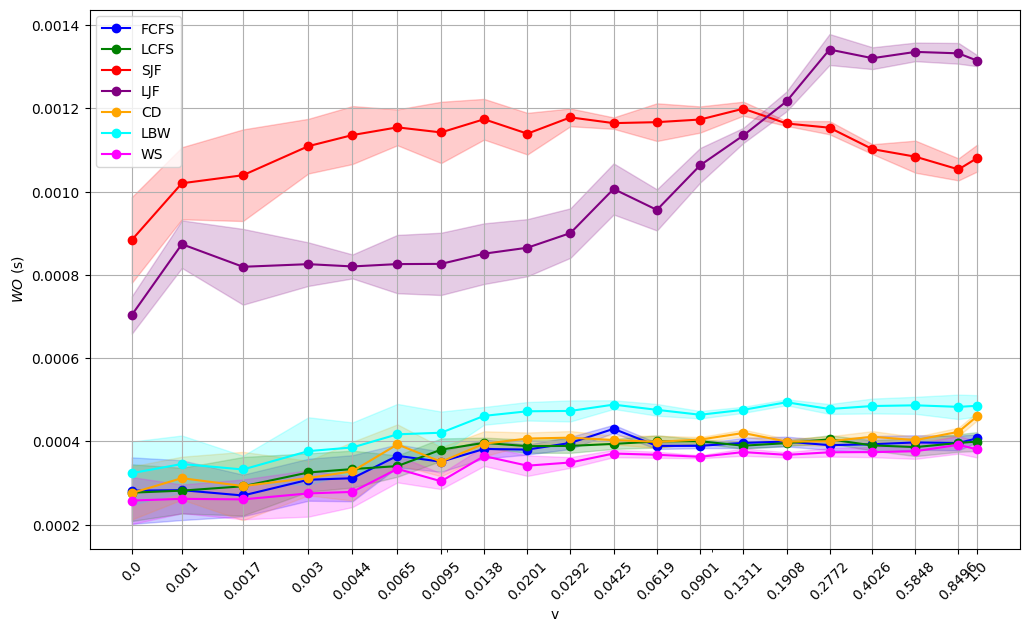

In [16]:
# Overhead
plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    plt.plot(variances, avg_overheads[heuristic], label=heuristic, marker='o', color=colors[heuristic])
    plt.fill_between(variances, 
                     [max(0, avg - std) for avg, std in zip(avg_overheads[heuristic], std_overheads[heuristic])],
                     [avg + std for avg, std in zip(avg_overheads[heuristic], std_overheads[heuristic])],
                     color=colors[heuristic], alpha=0.2)

plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$WO$ (s)')
#plt.title('Average±STD Worker Overhead Results per Heuristic')
plt.legend()
plt.grid(True)

plt.savefig(figPath + 'aggregated_worker_overhead_results.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

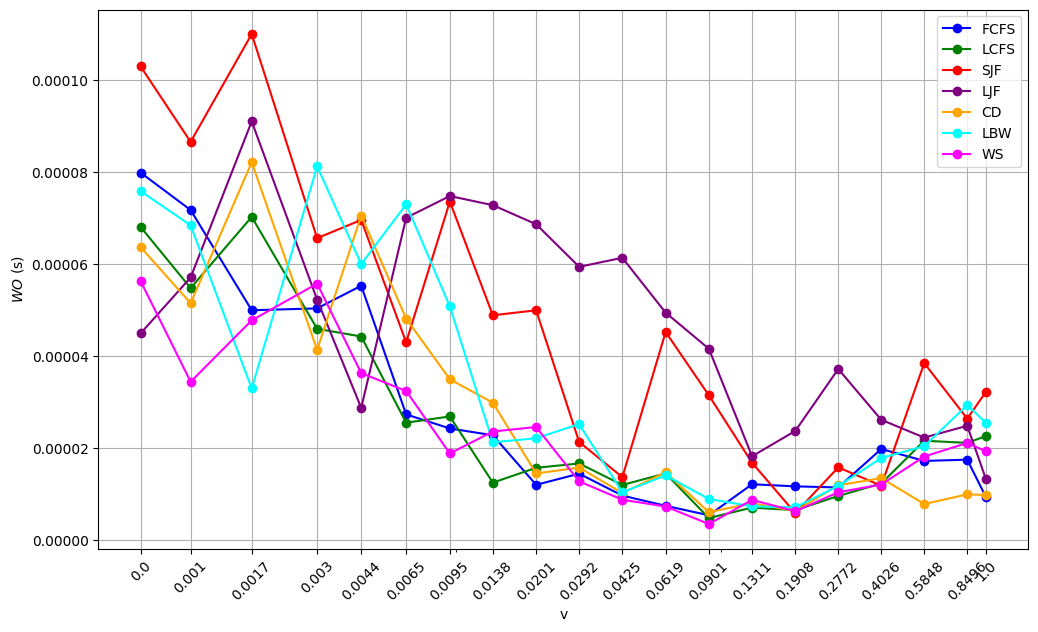

In [17]:
# Overhead
plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    plt.plot(variances, std_overheads[heuristic], label=heuristic, marker='o', color=colors[heuristic])

plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$WO$ (s)')
#plt.title('Average±STD Worker Overhead Results per Heuristic')
plt.legend()
plt.grid(True)

plt.savefig(figPath + 'overhead_variability.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

#### 2. Task Time Distribution Clustering per Heuristic

**Phenomenon:**
Heuristics like SJF consistently allocate longer task times to initial workers compared to FCFS, LCFS, and WS, indicating a deliberate front-loading of execution-heavy tasks.

**Visualization:**
Boxplots per Heuristic: X-axis: Worker Index, Y-axis: Task Time.
Separate subplots for SJF vs. FCFS/LCFS/WS for clearer contrast.

**Interpretation:**
SJF's front-loaded task time distribution reflects its design principle of minimizing global execution time but could lead to worker under-utilization in dynamic environments.

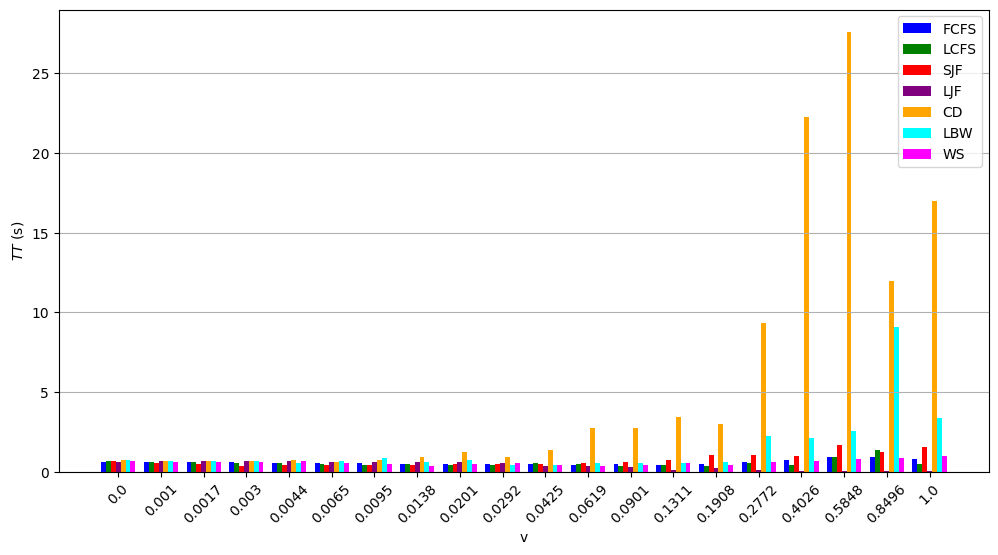

In [18]:
bar_width = 0.8/len(heuristics)

x = np.arange(len(variances))

series = [[stats.stdev([Wdata[h_id][v_id][i][0] for i in range(n_worker)]) for v_id in range(len(variances))] for h_id in range(len(heuristics))]

plt.figure(figsize=figSize['S'])
for h_id, heuristic in enumerate(heuristics):
    offset = (h_id - len(heuristics)/2) * bar_width + bar_width/2
    plt.bar(x + offset, series[h_id], width=bar_width, label=heuristic, color=colors[heuristic])

plt.xlabel('v')
plt.xticks(x, variances, rotation=45)
plt.ylabel(r'$TT$ (s)')
#plt.title(f'Deviation of worker total task time per variances')
plt.legend()
plt.grid(axis='y')

plt.savefig(figPath + 'deviation_worker_task_time.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

In [19]:
#Add the boxplots for the most interesting ones here

#Can't do the real one yet, need to restart while registering which task for which worker when printing out task time

#### 3. Load-Balancing Heuristics (LBW, WS) Mitigate Overhead but at Task Time Cost

**Phenomenon:**
LBW and WS maintain low variance in overhead growth, but they assign consistently longer task times to individual tasks compared to FCFS/LCFS.

**Visualization:**
Scatter Plot: X-axis: Task Time, Y-axis: Overhead per Task, color-coded by Heuristic.
Trendlines for LBW/WS vs. FCFS/LCFS.

**Interpretation:**
Load-balancing heuristics effectively distribute overhead but do so at the cost of task time efficiency, reflecting a trade-off between execution speed per task and overall system balance.

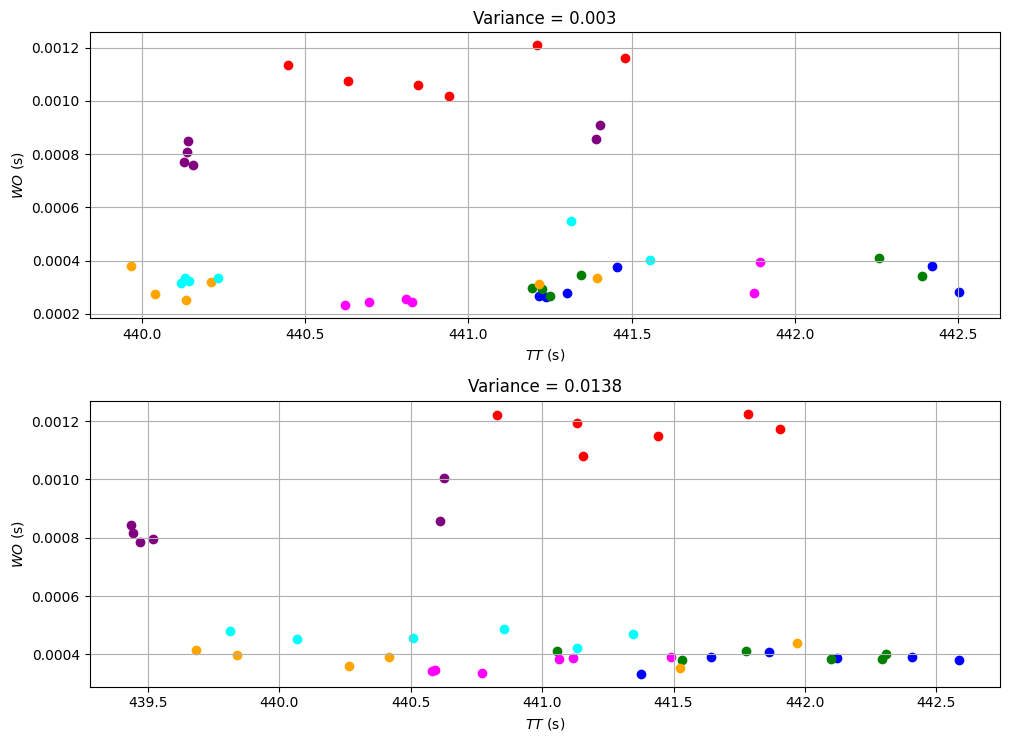

In [20]:
import matplotlib.pyplot as plt

# Pick four variance indices to show
variance_ids = [3, 7, 12, 16]   # <-- change to whichever four you want
fig, axes = plt.subplots(2, 1, figsize=figSize['L'], sharex=False, sharey=False)
axes = axes.ravel()

for idx, (ax, v_id) in enumerate(zip(axes, variance_ids)):
    task_times = []
    overheads = []
    labels = []

    # Collect data for this variance
    for h_id, heuristic in enumerate(heuristics):
        for task_time, overhead in Wdata[h_id][v_id]:
            task_times.append(task_time)
            overheads.append(overhead)
            labels.append(heuristic)

    # Scatter per heuristic
    for heuristic in heuristics:
        xs = [t for t, h in zip(task_times, labels) if h == heuristic]
        ys = [o for o, h in zip(overheads, labels) if h == heuristic]
        ax.scatter(xs, ys, label=heuristic, color=colors[heuristic])

    ax.set_xlabel(r"$TT$ (s)")
    ax.set_ylabel(r"$WO$ (s)")
    ax.set_title(f"Variance = {variances[v_id]}")
    ax.grid(True)


#fig.suptitle("Task Time vs Overhead at Different Variance Parameters", y=0.95)
fig.tight_layout(rect=[0, 0, 0.85, 0.94])

plt.savefig(figPath + 'task_time_vs_overhead_four_variances.png',
            bbox_inches='tight', pad_inches=pad_inches)
plt.show()


#### 4. RR Heuristic Exhibits Variance Sensitivity and Scheduling Instability

**Phenomenon:**
RR shows significant deviations in overhead (overhead spikes at variance = 0.31, 0.56, 1.0), unlike other heuristics which show smoother overhead increases.

**Visualization:**
Variance vs. Overhead Variance Plot (Error Bars): X-axis: Variance, Y-axis: Standard Deviation of Overhead across Workers, for RR vs. others.

**Interpretation:**
Round Robin's simplistic scheduling fails under high workload variability, making it unsuitable for environments with unpredictable task profiles.

##### Task Time Variability

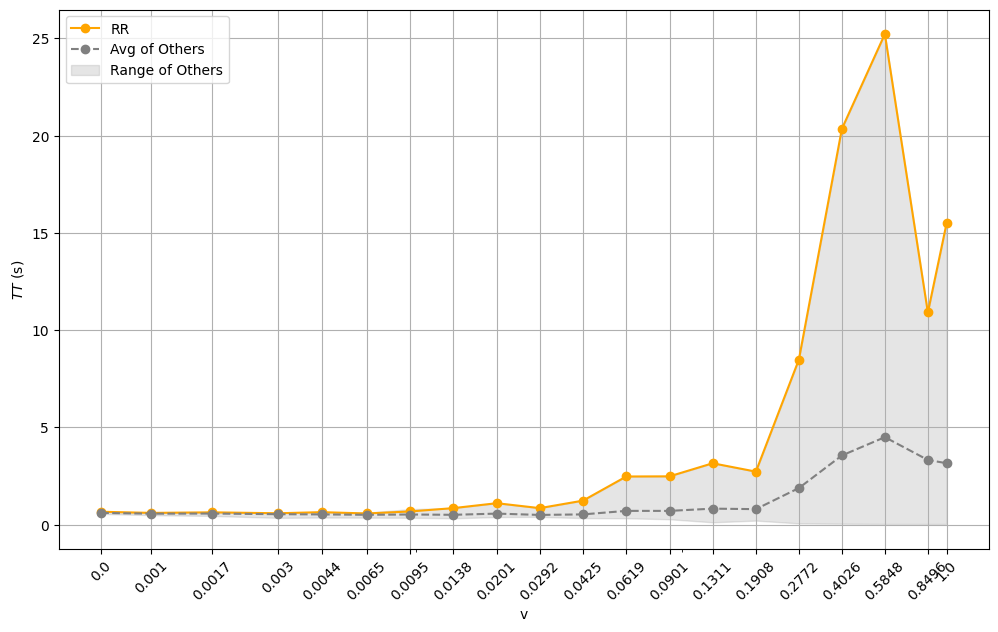

In [21]:
# Plotting Subplots
plt.figure(figsize=figSize['M'])


# Left subplot: Task Time Standard Deviation (Shaded Zone for Others)
rr_std = std_tasks['CD']
others_min_std = []
others_max_std = []
others_avg_std = []

for v_id in range(n_v):
    other_stds = [std_tasks[heuristic][v_id] for heuristic in heuristics if heuristic != 'RR']
    avg_std = np.mean(other_stds)
    others_avg_std.append(avg_std)
    others_min_std.append(np.min(other_stds))
    others_max_std.append(np.max(other_stds))

# Left subplot: Task Time Standard Deviation
plt.plot(variances, rr_std, label='RR', marker='o', color='orange')
plt.plot(variances, others_avg_std, label='Avg of Others', marker='o', linestyle='--', color='gray')
plt.fill_between(variances, others_min_std, others_max_std, color='gray', alpha=0.2, label='Range of Others')
plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$TT$ (s)')
#plt.title('Task Time Variability: RR vs Others')
plt.legend()
plt.grid(True)

plt.savefig(figPath + 'task_time_variability_cd.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

##### Overhead Variability

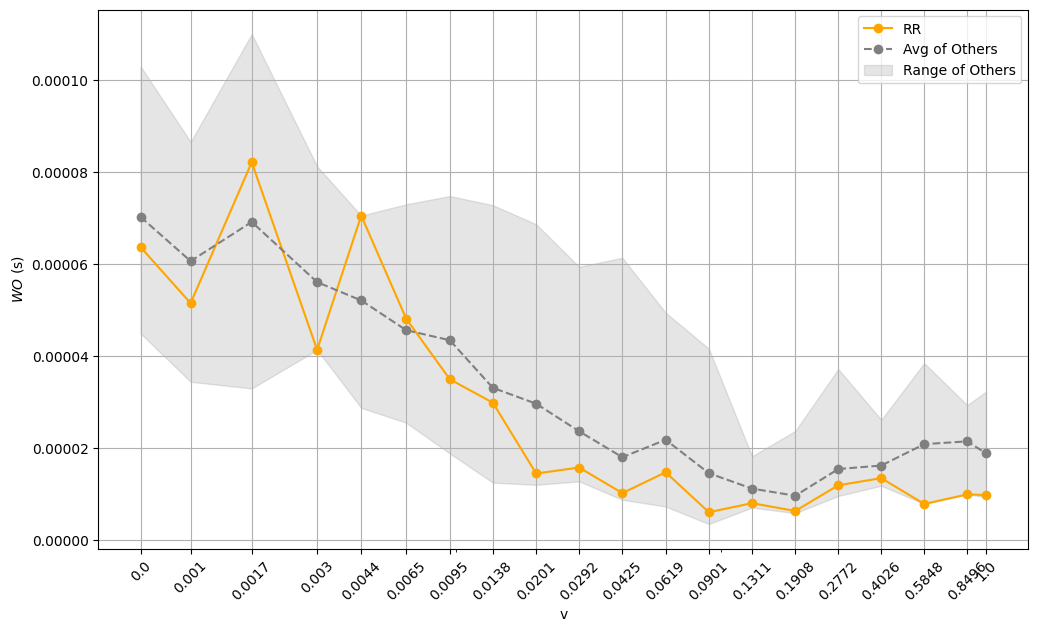

In [22]:
# Plot RR vs Average of Others
rr_std = std_overheads['CD']
others_avg_std = []
others_min_std = []
others_max_std = []

for v_id in range(n_v):
    other_stds = [std_overheads[heuristic][v_id] for heuristic in heuristics if heuristic != 'RR']
    others_min_std.append(np.min(other_stds))
    others_max_std.append(np.max(other_stds))
    avg_std = np.mean(other_stds)
    others_avg_std.append(avg_std)

plt.figure(figsize=figSize['M'])

plt.plot(variances, rr_std, label='RR', marker='o', color='orange')
plt.plot(variances, others_avg_std, label='Avg of Others', marker='o', linestyle='--', color='gray')
plt.fill_between(variances, others_min_std, others_max_std, color='gray', alpha=0.2, label='Range of Others')
plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$WO$ (s)')
#plt.title('Overhead Variability: RR vs Others')
plt.legend()
plt.grid(True)

plt.savefig(figPath + 'overhead_variability_cd.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

##### Task time per worker RR

In [23]:
# Extract RR task times
worker_times = [[] for _ in range(n_worker)]

for worker_id in range(n_worker):
    for v_id in range(n_v):
        worker_times[worker_id].append(Wdata[4][v_id][worker_id][0])

    print(f"Worker {worker_id}: {worker_times[worker_id]}")

Worker 0: [440.172437, 441.745173, 441.52442, 441.214794, 441.803595, 441.808169, 441.676575, 441.523148, 441.321009, 440.899889, 441.922235, 445.447666, 444.570556, 445.366565, 443.064093, 452.826961, 464.264554, 508.156648, 509.30851, 493.419575]
Worker 1: [440.190315, 441.897839, 441.467309, 441.393561, 441.585835, 441.688863, 441.513041, 441.970753, 441.913269, 440.592423, 442.25488, 443.114024, 442.595607, 448.718788, 441.716274, 450.387052, 434.237591, 471.687069, 519.307738, 512.371352]
Worker 2: [438.773388, 440.589387, 440.161971, 439.96639, 440.385487, 440.797622, 440.186233, 439.68358, 439.768668, 439.02851, 441.058112, 437.680092, 437.306249, 441.227652, 447.596583, 464.251677, 489.705478, 449.516438, 514.886661, 471.656724]
Worker 3: [438.730745, 440.648893, 440.192529, 440.039175, 440.305881, 440.340369, 440.056922, 439.8413, 441.450607, 439.945571, 438.496272, 440.442579, 441.452334, 444.203275, 443.806481, 451.023598, 468.99288, 500.972827, 491.893195, 508.550988]
Worke

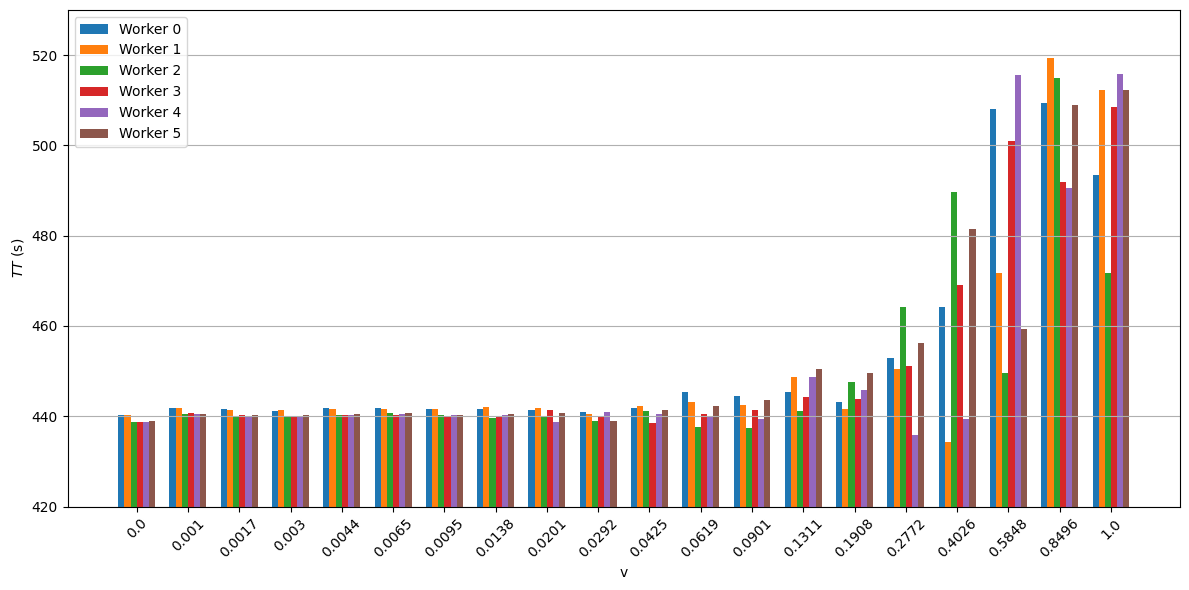

In [24]:
# Grouped Bar Plot
bar_width = 0.12
x = np.arange(n_v)  # Base positions for each variance group

plt.figure(figsize=figSize['S'])

for worker_id in range(n_worker):
    offset = (worker_id - (n_worker - 1) / 2) * bar_width
    plt.bar(x + offset, worker_times[worker_id], width=bar_width, label=f'Worker {worker_id}')

# Formatting
plt.xticks(ticks=x, labels=variances, rotation=45)
plt.ylim((420, 530))
plt.xlabel('v')
plt.ylabel(r'$TT$ (s)')
#plt.title('Round Robin: Task Time per Worker across Variance Parameters')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()

plt.savefig(figPath + 'cd_task_time_per_worker.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

#### 5. Divergence of FCFS and LCFS under High Variance
Phenomenon:
At low variances, FCFS and LCFS are nearly identical in overhead and task time distributions. At higher variances (≥ 0.56), LCFS starts performing slightly better in overhead, suggesting a divergence in their load-balancing efficiency.

Visualization:
Dual Line Chart: X-axis: Variance, Y-axis: Average Overhead, separate lines for FCFS and LCFS.
Highlight divergence regions with annotations.

Interpretation:
Though similar in design, LCFS demonstrates a marginal advantage in handling high-variance workloads, likely due to its implicit adaptation to newer task influxes.

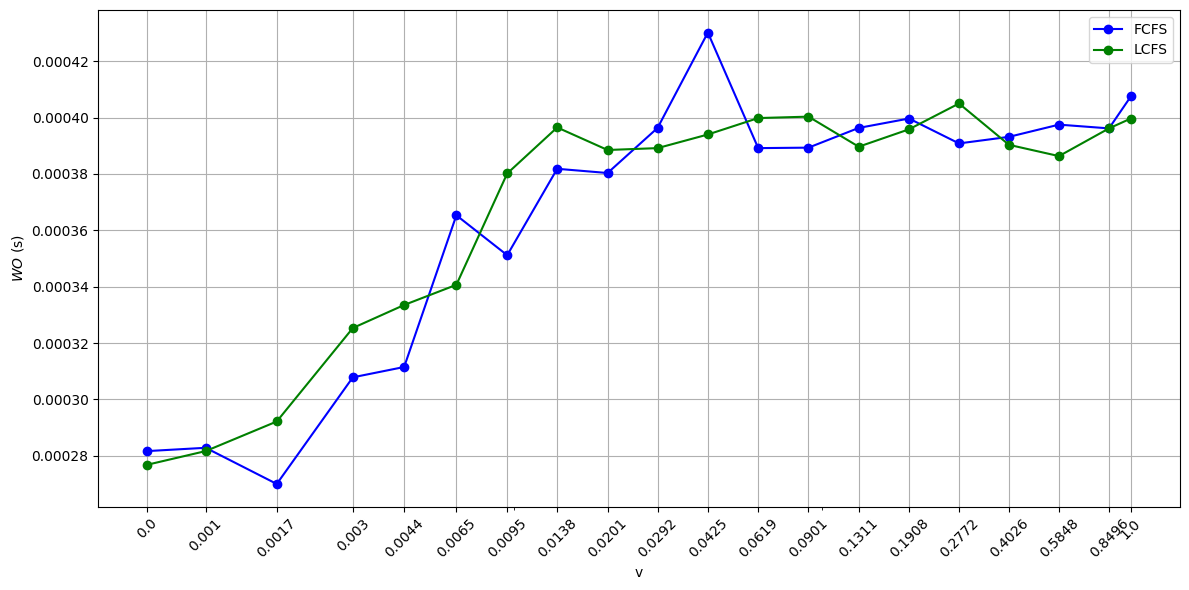

In [25]:
fcfs_avg_overhead = []
lcfs_avg_overhead = []

for v_id in range(n_v):
    fcfs_oh = [pair[1] for pair in Wdata[0][v_id]]
    lcfs_oh = [pair[1] for pair in Wdata[1][v_id]]
    fcfs_avg_overhead.append(np.mean(fcfs_oh))
    lcfs_avg_overhead.append(np.mean(lcfs_oh))

# Plotting
plt.figure(figsize=figSize['S'])
plt.plot(variances, fcfs_avg_overhead, label='FCFS', marker='o', color=colors['FCFS'])
plt.plot(variances, lcfs_avg_overhead, label='LCFS', marker='o', color=colors['LCFS'])


plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$WO$ (s)')
#plt.title('Comparison of FCFS and LCFS')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(figPath + 'fcfs_vs_lcfs_overhead.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

#### 6. Longest Job First (LJF) Shows Anomalous Stability in High Variance Overhead
Phenomenon:
LJF maintains nearly constant overhead increases, even as variance grows, outperforming expectation given its theoretical scheduling bias towards large tasks.

Visualization:
Line Chart Overlay: X-axis: Variance, Y-axis: Average Overhead for LJF vs. other heuristics.
Confidence bands around LJF’s line to visualize its low variance.

Interpretation:
LJF's unexpected stability suggests that prioritizing heavier tasks might inherently absorb variance-induced scheduling noise, making it a robust strategy in high-load systems.

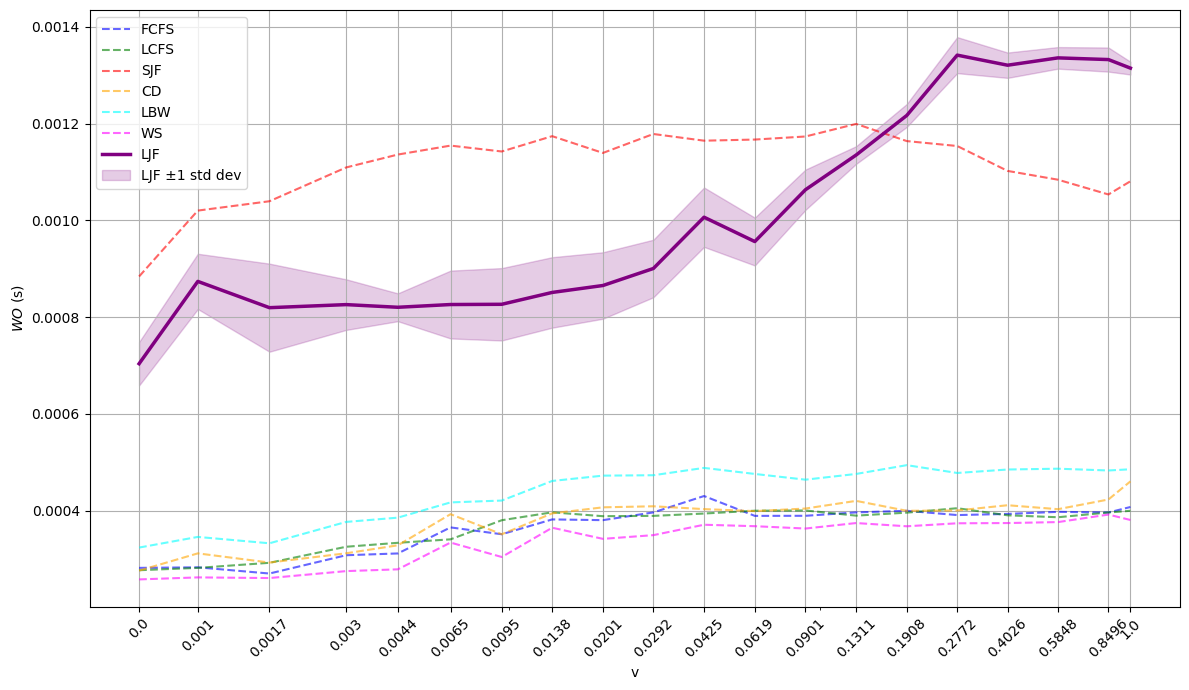

In [26]:
# Plotting
plt.figure(figsize=figSize['M'])

# Plot other heuristics
for heuristic in heuristics:
    if heuristic != 'LJF':
        plt.plot(variances, avg_overheads[heuristic], label=heuristic, linestyle='--', alpha=0.6, color=colors[heuristic])

# Plot LJF with confidence band
ljf_avg = avg_overheads['LJF']
ljf_std = std_overheads['LJF']
ljf_upper = [m + s for m, s in zip(ljf_avg, ljf_std)]
ljf_lower = [m - s for m, s in zip(ljf_avg, ljf_std)]

plt.plot(variances, ljf_avg, label='LJF', color=colors['LJF'], linewidth=2.5)
plt.fill_between(variances, ljf_lower, ljf_upper, color=colors['LJF'], alpha=0.2, label='LJF ±1 std dev')

# Formatting
plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$WO$ (s)')
#plt.title('LJF Overhead Evolution vs Other Heuristics')
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.savefig(figPath + 'ljf_overhead_evolution.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

#### 8. Worst case worker performance

what: max overhead of workers per heuristic per variance

why: Highlights if a heuristic consistently creates bottlenecks

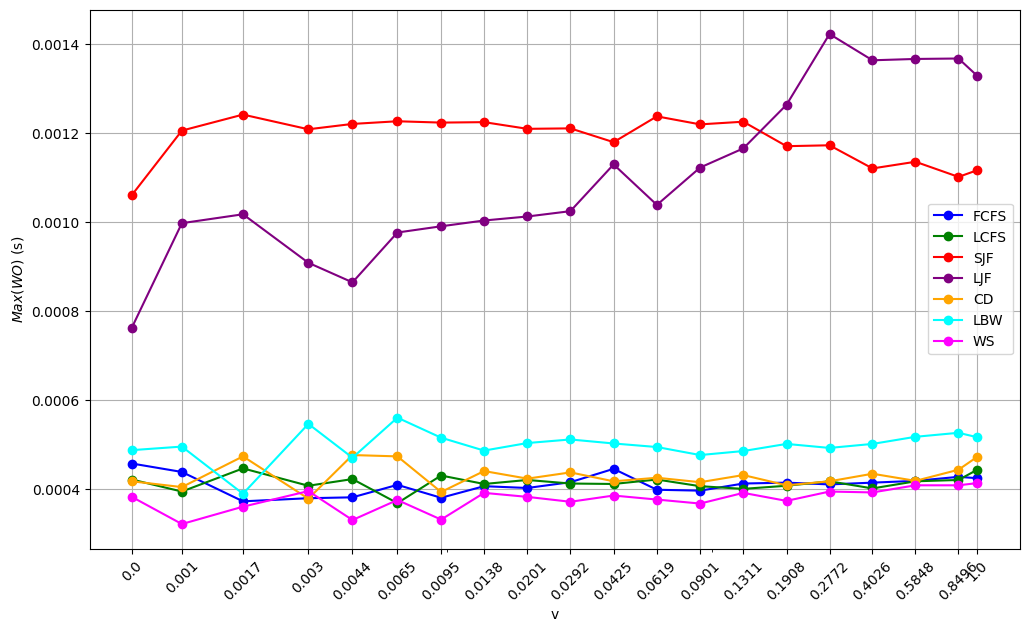

In [27]:
max_overheads = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        overheads = [entry[1] for entry in Wdata[h_id][v_id]]
        max_overheads[heuristic].append(np.max(overheads))

plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    plt.plot(variances, max_overheads[heuristic], label=heuristic, marker='o', color=colors[heuristic])
plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$Max (WO)$ (s)')
#plt.title('Worst Case Worker Overhead per Heuristic')
plt.legend()
plt.grid(True)

#plt.savefig(figPath + 'worst_case_worker_overhead.png', bbox_inches='tight', pad_inches=pad_inches)
#plt.show()

#### 9. Lost worker time

We consider time lost when a worker is done and waiting for other workers to finish to close.

= sum of (makespan - finish time) per worker for all workers

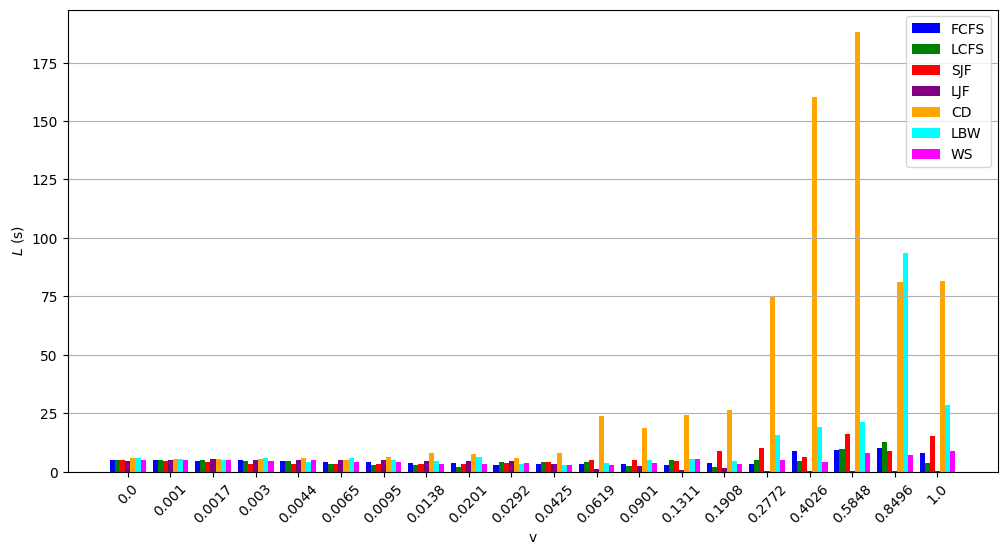

In [34]:
lost_time = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        makespan = max([entry[0] for entry in Wdata[h_id][v_id]]) #Max worker task time
        total_lost = sum(makespan - entry[0] for entry in Wdata[h_id][v_id]) #Sum of (makespan - worker task time)
        lost_time[heuristic].append(total_lost)

        #print(f"Heuristic {heuristic}, Variance {variances[v_id]}: Makespan = {makespan}, Total Lost Time = {total_lost}")

plt.figure(figsize=figSize['S'])

for h_id, heuristic in enumerate(heuristics):
    offset = (h_id - len(heuristics)/2) * bar_width + bar_width/2
    plt.bar(x + offset, lost_time[heuristic], width=bar_width, label=heuristic, color=colors[heuristic])

plt.xlabel('v')
plt.xticks(x, variances, minor=False, rotation=45)
plt.ylabel(r'$L$ (s)')
#plt.title(f'Worker time lost per heuristic')
plt.legend()
plt.grid(axis='y')

plt.savefig(figPath + 'worker_time_lost_per_heuristic.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

#### Task time to Overhead Ratio

In [29]:
ttor_data = {heuristic: [[] for v_id in range(n_v)] for heuristic in heuristics}
ttor_std = {heuristic: [[] for v_id in range(n_v)] for heuristic in heuristics}

for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        ratios = []
        for entry in Wdata[h_id][v_id]:
            ratios.append(entry[1] / entry[0] if entry[0] > 0 else 0)
        ttor_data[heuristic][v_id] = np.mean(ratios)
        ttor_std[heuristic][v_id] = np.std(ratios)

        print(f"Heuristic {heuristic}, Variance {variances[v_id]}: Avg TTOR = {ttor_data[heuristic][v_id]}, Std TTOR = {ttor_std[heuristic][v_id]}")

Heuristic FCFS, Variance 0.0: Avg TTOR = 6.383669004342034e-07, Std TTOR = 1.8044419985222497e-07
Heuristic FCFS, Variance 0.001: Avg TTOR = 6.399913668521227e-07, Std TTOR = 1.618119490363241e-07
Heuristic FCFS, Variance 0.0017: Avg TTOR = 6.10800929238878e-07, Std TTOR = 1.123790743907354e-07
Heuristic FCFS, Variance 0.003: Avg TTOR = 6.968905791957881e-07, Std TTOR = 1.1378081243664086e-07
Heuristic FCFS, Variance 0.0044: Avg TTOR = 7.052614634625427e-07, Std TTOR = 1.2476819479809965e-07
Heuristic FCFS, Variance 0.0065: Avg TTOR = 8.26381755807814e-07, Std TTOR = 6.126919254505527e-08
Heuristic FCFS, Variance 0.0095: Avg TTOR = 7.945618292234661e-07, Std TTOR = 5.441408549981483e-08
Heuristic FCFS, Variance 0.0138: Avg TTOR = 8.638559938674296e-07, Std TTOR = 5.1370324373190613e-08
Heuristic FCFS, Variance 0.0201: Avg TTOR = 8.612569997702067e-07, Std TTOR = 2.7427851620075506e-08
Heuristic FCFS, Variance 0.0292: Avg TTOR = 8.989438729252308e-07, Std TTOR = 3.248572222667243e-08
He

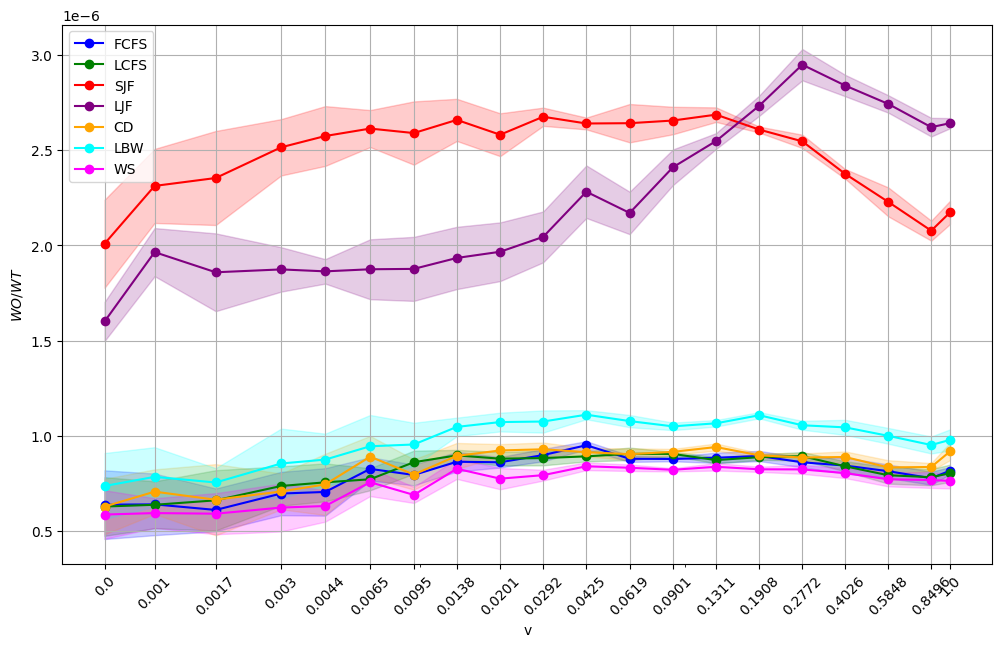

In [30]:
plt.figure(figsize=figSize['M'])
for h_id, heuristic in enumerate(heuristics):
    plt.plot(variances, ttor_data[heuristic], label=heuristic, marker='o', color=colors[heuristic])
    plt.fill_between(variances, 
                     [m - s for m, s in zip(ttor_data[heuristic], ttor_std[heuristic])],
                     [m + s for m, s in zip(ttor_data[heuristic], ttor_std[heuristic])],
                     color=colors[heuristic], alpha=0.2)
plt.xlabel('v')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel(r'$WO/WT$')
#plt.title('Worker Overhead to Task Time Ratio and Standard Deviation per Heuristic')
plt.legend()
plt.grid(True)

plt.savefig(figPath + 'overhead_to_task_time_ratio.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

In [31]:
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        print(f"Heuristic {heuristic}, Variance {variances[v_id]}:{Sdata[h_id][v_id]}")

Heuristic FCFS, Variance 0.0:0.003646
Heuristic FCFS, Variance 0.001:0.003664
Heuristic FCFS, Variance 0.0017:0.003634
Heuristic FCFS, Variance 0.003:0.003787
Heuristic FCFS, Variance 0.0044:0.003611
Heuristic FCFS, Variance 0.0065:0.003675
Heuristic FCFS, Variance 0.0095:0.003486
Heuristic FCFS, Variance 0.0138:0.003526
Heuristic FCFS, Variance 0.0201:0.003533
Heuristic FCFS, Variance 0.0292:0.003479
Heuristic FCFS, Variance 0.0425:0.003751
Heuristic FCFS, Variance 0.0619:0.003801
Heuristic FCFS, Variance 0.0901:0.00354
Heuristic FCFS, Variance 0.1311:0.003406
Heuristic FCFS, Variance 0.1908:0.003439
Heuristic FCFS, Variance 0.2772:0.003549
Heuristic FCFS, Variance 0.4026:0.003472
Heuristic FCFS, Variance 0.5848:0.003314
Heuristic FCFS, Variance 0.8496:0.003369
Heuristic FCFS, Variance 1.0:0.003353
Heuristic LCFS, Variance 0.0:0.003656
Heuristic LCFS, Variance 0.001:0.003811
Heuristic LCFS, Variance 0.0017:0.003774
Heuristic LCFS, Variance 0.003:0.003648
Heuristic LCFS, Variance 0.004

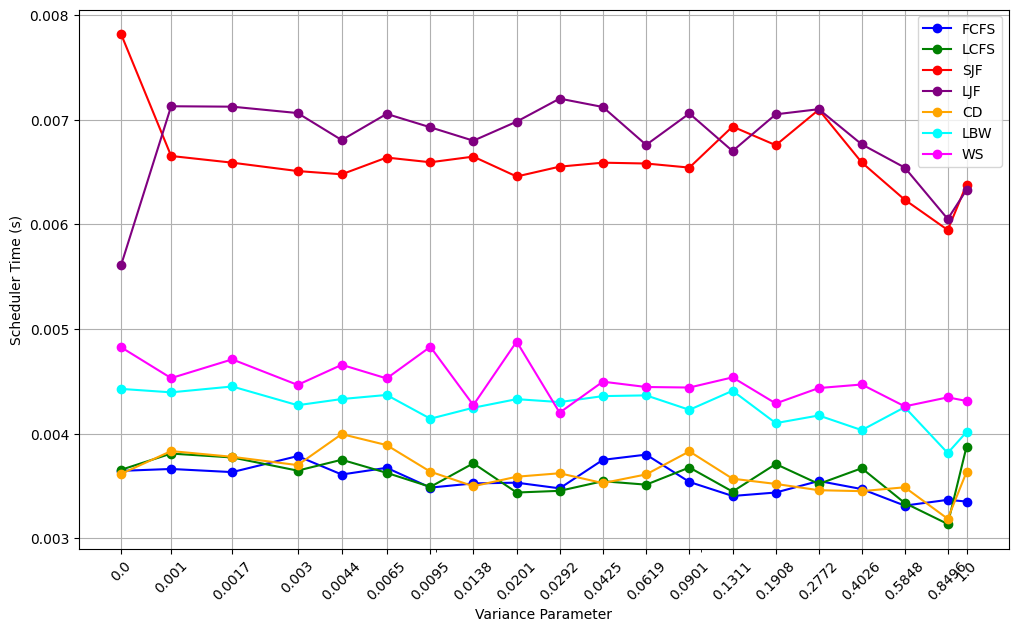

In [32]:
plt.figure(figsize=figSize['M'])

for h_id, heuristic in enumerate(heuristics):
    plt.plot(variances, Sdata[h_id], 
             label=f'{heuristic}', marker='o', color=colors[heuristic])
    
plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel('Scheduler Time (s)')
#plt.title('Scheduling Time per Heuristic')
plt.legend()
plt.grid(True)

plt.savefig(figPath + 'scheduling_time_per_heuristic.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()

<Figure size 1200x700 with 0 Axes>

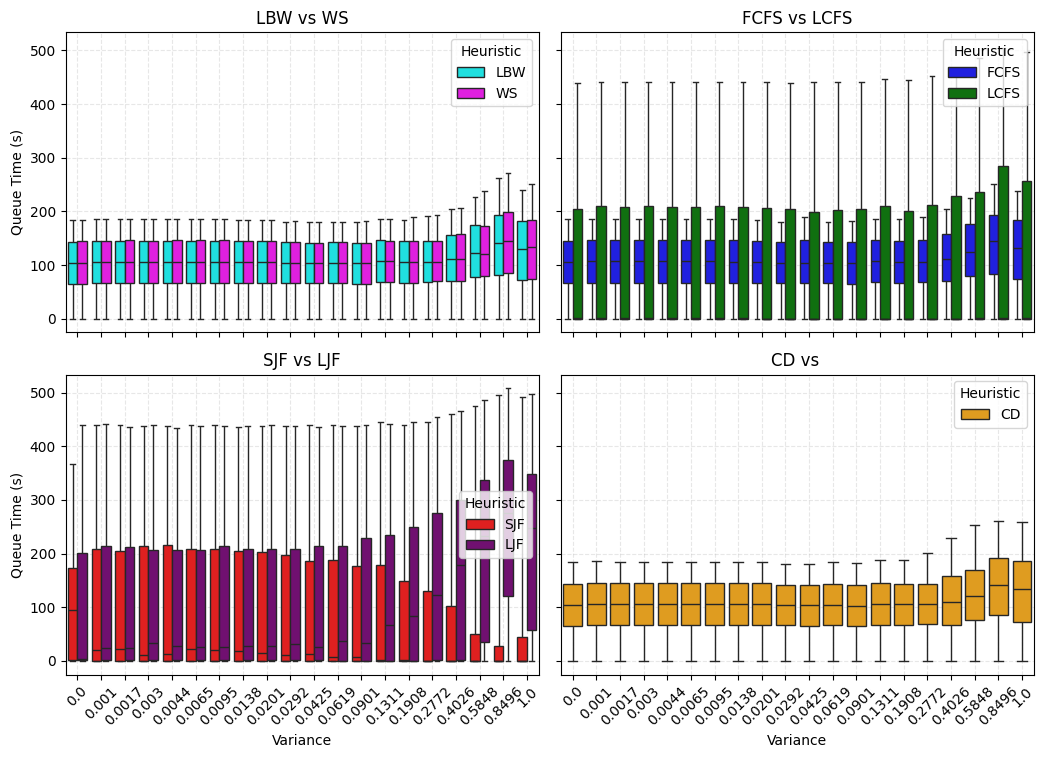

In [33]:
plt.figure(figsize=figSize['M'])


# Try to ensure numeric ordering of the variance axis
try:
    Tdf["Variance"] = Tdf["Variance"].astype(float)
    x_order = sorted(Tdf["Variance"].unique())
except Exception:
    x_order = sorted(Tdf["Variance"].unique(), key=lambda x: str(x))


# --- Choose which heuristic(s) go in each panel (edit this) ---
panel_heuristics = [
    ("LBW", "WS"),     # top-left
    ("FCFS", "LCFS"),  # top-right
    ("SJF","LJF"),          # bottom-left
    ("CD",'')            # bottom-right
]

plot_kind = "box"   # "box" or "violin"
sharey = True       # share y-axis across subplots

# --- Create 2x2 grid and plot ---
fig, axes = plt.subplots(2, 2, figsize=figSize['L'], sharey=sharey)
axes = axes.ravel()


for idx, (ax, heur_subset) in enumerate(zip(axes, panel_heuristics)):
    subset = Tdf[Tdf["Heuristic"].isin(heur_subset)].copy()

    if plot_kind == "violin":
        sns.violinplot(
            data=subset,
            x="Variance", y="QueueTime", hue="Heuristic",
            order=x_order,
            palette=colors,
            inner="box", cut=0,
            ax=ax
        )
    else:
        sns.boxplot(
            data=subset,
            x="Variance", y="QueueTime", hue="Heuristic",
            order=x_order,
            palette=colors,
            ax=ax,
            whis=(0, 100)
        )

    # cosmetics
    ax.set_xlabel("Variance")
    ax.set_ylabel("Queue Time (s)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_title(" vs ".join(heur_subset) if len(heur_subset) > 1 else heur_subset[0])

    # Rotate xticks for bottom row only
    if idx in (0,1):  # top row
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.tick_params(axis="x", rotation=45)

#fig.suptitle("Queue Time Distribution by Variance — 4-Panel Comparison", y=0.98)
fig.tight_layout(rect=[0, 0, 0.88, 0.96])

plt.savefig(figPath + 'queue_time_distribution_comparison.png', bbox_inches='tight', pad_inches=pad_inches)
plt.show()